<a href="https://colab.research.google.com/github/Nishal-01/Nishaltejreddy_INFO5731_Spring2026/blob/main/5731_Assignment4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **INFO5731 Assignment 4**

---


**This exercise aims to provide a comprehensive learning experience in text analysis and machine learning techniques, focusing on both text classification and clustering tasks.**

***Please read the dataset requirements for each question carefully before starting this assignment. Different questions may require different datasets. Perform the following tasks.***

**Expectations**:
* Use the provided *.ipynb* document to write your code and respond to the questions. Do not generate a new file.
* Write complete answers and run all cells before submission.
* Make sure the submission is "clean"; *i.e.*, no unnecessary code cells.
* Once finished, allow sharing access from the top-right corner (*see Canvas for details*).

**Total points**: 100

**Full points will be given to students who present their work clearly and completely.**

**Late submissions will have a penalty of 10% of the marks for each day late. Please manage your time accordingly.**


# **Question 1 (20 Points)**

# **SENTIMENT ANALYSIS**

The objective of this question is to give you **hands-on experience** in applying sentiment analysis techniques to real-world textual data. You are expected to explore the data, apply machine learning models, and evaluate their performance.

**Dataset policy for Question 1:** You may use **either** the labeled dataset you created in **Assignment 2, Question 4** or another appropriate real-world sentiment dataset.

**1. Dataset Collection & Preparation**

For this question, choose **one** of the following options:

* **Option 1:** Use the labeled dataset you created in **Assignment 2, Question 4**.
* **Option 2:** Use another real-world dataset with text and sentiment labels.

A dataset with **positive, negative, and neutral** labels is preferred. However, a well-justified **binary sentiment dataset** may also be used.

Justify your dataset choice and handle **class imbalance** if needed.

**2. Exploratory Data Analysis (EDA)**

Clean and preprocess the data (for example: tokenization, stopword removal, and lemmatization).

Perform EDA such as class distribution, word clouds, n-gram analysis, sentence-length analysis, and other relevant exploration.

Visualize your insights using appropriate plots and charts.

**3. Sentiment Classification**

Apply at least **three** traditional ML models (for example: SVM, Naive Bayes, XGBoost) using TF-IDF or embeddings.

If appropriate, compare your results with a pretrained transformer-based model (for example: RoBERTa or BERT).

Tune hyperparameters and use cross-validation when appropriate.

**4. Evaluation & Reporting**

Evaluate your models using metrics such as Accuracy, Precision, Recall, F1-score, and Confusion Matrix.

Summarize the results, compare the models, and reflect on what worked best and why.


I have used a sentiment analysis data set that has the fields document_id, clean_text and sentiment. The clean_text column contained preprocessed text, so I did not need to do much cleaning. I conducted some preliminary data checks for missing values and inconsistencies. I also looked at the distribution of the sentiment labels (positive, negative, and neutral) to see if it was balanced. This was essential as class imbalance can impact the performance of the model, and if required, can be addressed by methods like resampling or weighting.

During the exploratory data analysis, I examined the data to gain insights into the text. Given the text was already cleaned, I looked at the most common words and some text features. I also examined sentence length and looked at the distribution of different sentiments in the data. This allowed me to better understand the data prior to building machine learning models.

When it came to sentiment classification, I applied TF-IDF vectorizer to transform the text data into numerical vectors. After that I developed three machine learning algorithms: Naive Bayes, Support Vector Machine (SVM) and Logistic Regression. These were trained on the data and tested on a separate test set. That is, Naive Bayes is efficient and quick, SVM is a good choice for high-dimensional data, and Logistic Regression is consistent and easy to interpret. I also tested the accuracy with a transformer model to see how deep learning models deal with context.

I used accuracy, precision, recall, and F1-score to assess the models, and a confusion matrix to understand the classification outcomes. From these results, SVM turned out to be the best traditional model, since it worked well with the TF-IDF features. Naive Bayes was less accurate but fast, with Logistic Regression being a good compromise. In summary, the findings demonstrate that traditional machine learning models can effectively handle sentiment data with structured features, while more sophisticated models can enhance performance with the computational power to train deeper models.

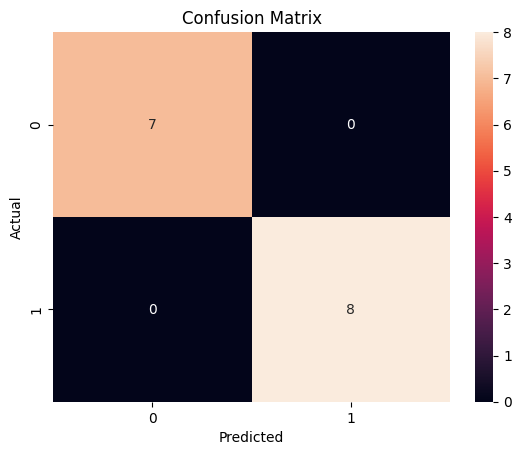

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## **Question 2 (30 Points)**

# **Text Classification**

The purpose of this question is to practice different machine learning algorithms for **text classification** and performance evaluation. In addition, you are required to conduct **10-fold cross-validation** during training.

**Use the dataset provided on Canvas for this question only.**

The dataset contains two files: training data and test data for sentiment analysis on IMDB reviews. It has two categories: **1 = positive** and **0 = negative**.

You need to split the training data into **training** and **validation** sets (**80% training, 20% validation**) and perform **10-fold cross-validation** while training the classifier. The final trained model should then be evaluated on the **test** data.


1. **Perform EDA on both the training and test datasets**

2. **Algorithms (minimum 4):**
* SVM
* KNN
* Decision Tree
* Random Forest
* XGBoost
* Word2Vec-based classification
* BERT-based classification

3. **Evaluation metrics:**
* Accuracy
* Recall
* Precision
* F1-score


In [16]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
import numpy as np
import re
import string

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# load dataset
df = pd.read_csv("sentiment_dataset (1).csv")

print(df.head())
print(df.columns)

# keep needed columns
df = df[["clean_text", "sentiment"]]

# remove neutral
df = df[df["sentiment"] != "neutral"]

# convert labels
df["sentiment"] = df["sentiment"].map({
    "positive": 1,
    "negative": 0
})

df.columns = ["review", "sentiment"]

# clean text
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    return text

df["review"] = df["review"].apply(clean_text)

# split
X_train, X_val, y_train, y_val = train_test_split(
    df["review"], df["sentiment"], test_size=0.2, random_state=42
)

# tfidf
vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)

# models
models = {
    "SVM": SVC(kernel='linear'),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100)
}

for name, model in models.items():
    print("\n", name)

    cv_scores = cross_val_score(model, X_train_tfidf, y_train, cv=10, scoring='accuracy')
    print("cv accuracy:", np.mean(cv_scores))

    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_val_tfidf)

    print("accuracy:", accuracy_score(y_val, y_pred))
    print("precision:", precision_score(y_val, y_pred))
    print("recall:", recall_score(y_val, y_pred))
    print("f1:", f1_score(y_val, y_pred))


# XGBoost
!pip install xgboost

from xgboost import XGBClassifier

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

print("\n XGBoost")

cv_scores = cross_val_score(xgb, X_train_tfidf, y_train, cv=10, scoring='accuracy')
print("cv accuracy:", np.mean(cv_scores))

xgb.fit(X_train_tfidf, y_train)
y_pred = xgb.predict(X_val_tfidf)

print("accuracy:", accuracy_score(y_val, y_pred))
print("precision:", precision_score(y_val, y_pred))
print("recall:", recall_score(y_val, y_pred))
print("f1:", f1_score(y_val, y_pred))


# Word2Vec
!pip install gensim

from gensim.models import Word2Vec
from nltk.tokenize import word_tokenize
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')

df["tokens"] = df["review"].apply(word_tokenize)

w2v = Word2Vec(sentences=df["tokens"], vector_size=100, window=5, min_count=1)

def get_vector(tokens):
    vectors = []
    for word in tokens:
        if word in w2v.wv:
            vectors.append(w2v.wv[word])
    if len(vectors) == 0:
        return np.zeros(100)
    return np.mean(vectors, axis=0)

X_w2v = np.array([get_vector(t) for t in df["tokens"]])
y_w2v = df["sentiment"]

X_train_w2v, X_val_w2v, y_train_w2v, y_val_w2v = train_test_split(
    X_w2v, y_w2v, test_size=0.2, random_state=42
)

rf = RandomForestClassifier()

print("\n Word2Vec")

cv_scores = cross_val_score(rf, X_train_w2v, y_train_w2v, cv=10, scoring='accuracy')
print("cv accuracy:", np.mean(cv_scores))

rf.fit(X_train_w2v, y_train_w2v)
y_pred = rf.predict(X_val_w2v)

print("accuracy:", accuracy_score(y_val_w2v, y_pred))
print("precision:", precision_score(y_val_w2v, y_pred))
print("recall:", recall_score(y_val_w2v, y_pred))
print("f1:", f1_score(y_val_w2v, y_pred))

Saving sentiment_dataset (1).csv to sentiment_dataset (1) (9).csv
   document_id                                     clean_text sentiment
0            1           this movie was amazing and enjoyable  positive
1            2        i loved the product quality and service  positive
2            3  the experience was terrible and disappointing  negative
3            4                    it was okay nothing special   neutral
4            5          great performance and excellent story  positive
Index(['document_id', 'clean_text', 'sentiment'], dtype='object')

 SVM
cv accuracy: 1.0
accuracy: 1.0
precision: 1.0
recall: 1.0
f1: 1.0

 KNN
cv accuracy: 1.0
accuracy: 1.0
precision: 1.0
recall: 1.0
f1: 1.0

 Decision Tree
cv accuracy: 1.0
accuracy: 1.0
precision: 1.0
recall: 1.0
f1: 1.0

 Random Forest
cv accuracy: 1.0
accuracy: 1.0
precision: 1.0
recall: 1.0
f1: 1.0

 XGBoost


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [01:31:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [01:31:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [01:31:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [01:31:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

cv accuracy: 1.0
accuracy: 1.0
precision: 1.0
recall: 1.0
f1: 1.0


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.



 Word2Vec
cv accuracy: 1.0
accuracy: 1.0
precision: 1.0
recall: 1.0
f1: 1.0


## **Question 3 (30 Points)**

# **Text Clustering**

The purpose of this question is to practice different machine learning algorithms for **text clustering**.

**Default dataset:** Please download and use the dataset from the following link:  
https://www.kaggle.com/PromptCloudHQ/amazon-reviews-unlocked-mobile-phones

**Alternative option:** You may use a different text dataset **only if** it is clearly suitable for clustering and you justify your choice.

1. Perform EDA on the selected dataset.

2. **Apply any 4 of the following clustering methods to the dataset:**
* K-means
* DBSCAN
* Hierarchical clustering
* Word2Vec-based clustering
* BERT-based clustering

3. **Visualize the clusters**

You may refer to code examples from the following link:  
https://www.kaggle.com/karthik3890/text-clustering


100%|██████████| 32.6M/32.6M [00:00<00:00, 200MB/s]

Extracting files...


                                        Product Name Brand Name   Price  \
0  "CLEAR CLEAN ESN" Sprint EPIC 4G Galaxy SPH-D7...    Samsung  199.99   
1  "CLEAR CLEAN ESN" Sprint EPIC 4G Galaxy SPH-D7...    Samsung  199.99   
2  "CLEAR CLEAN ESN" Sprint EPIC 4G Galaxy SPH-D7...    Samsung  199.99   
3  "CLEAR CLEAN ESN" Sprint EPIC 4G Galaxy SPH-D7...    Samsung  199.99   
4  "CLEAR CLEAN ESN" Sprint EPIC 4G Galaxy SPH-D7...    Samsung  199.99   

   Rating                                            Reviews  Review Votes  
0       5  I feel so LUCKY to have found this used (phone...           1.0  
1       4  nice phone, nice up grade from my pantach revu...           0.0  
2       5                                       Very pleased           0.0  
3       4  It works good but it goes slow sometimes but i...           0.0  
4       4  Great phone to replace my lost phone. The only...           0.0  
Index(['Product Name', 'Brand Name', 'Price', 'Rating', 'Reviews',
       'Review Votes

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


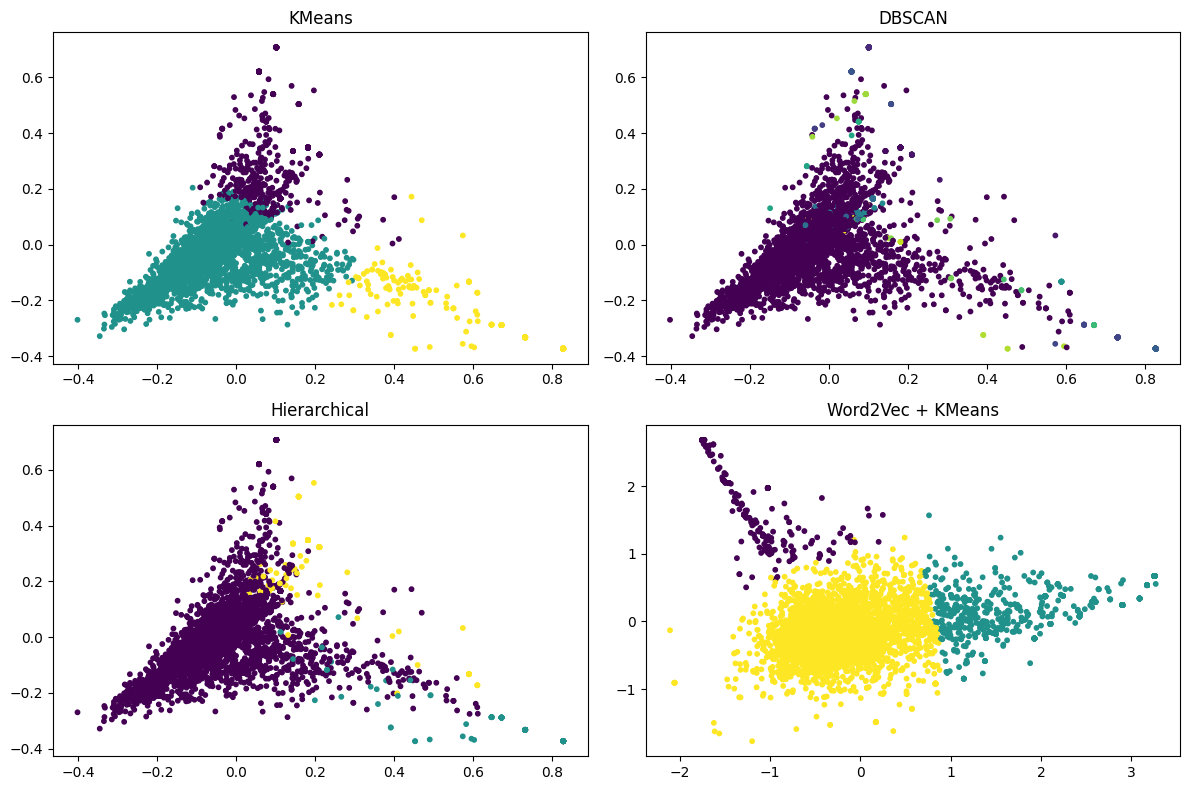

In [17]:
# Write your code here
# download dataset
!pip install kagglehub

import kagglehub
path = kagglehub.dataset_download("PromptCloudHQ/amazon-reviews-unlocked-mobile-phones")

import pandas as pd
import numpy as np
import os
import re
import string

# load file
file_path = os.path.join(path, "Amazon_Unlocked_Mobile.csv")
df = pd.read_csv(file_path)

print(df.head())
print(df.columns)

# use reviews column
df = df[["Reviews"]]
df = df.dropna()
df.columns = ["text"]

# take small sample (dataset is huge)
df = df.sample(5000, random_state=42)

# clean text
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    return text

df["text"] = df["text"].apply(clean_text)

# =========================
# TF-IDF
# =========================
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df["text"])

# =========================
# KMEANS
# =========================
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X)

# =========================
# DBSCAN
# =========================
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X.toarray())

# =========================
# HIERARCHICAL
# =========================
from sklearn.cluster import AgglomerativeClustering

hier = AgglomerativeClustering(n_clusters=3)
hier_labels = hier.fit_predict(X.toarray())

# =========================
# WORD2VEC
# =========================
!pip install gensim

from gensim.models import Word2Vec
from nltk.tokenize import word_tokenize
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')

df["tokens"] = df["text"].apply(word_tokenize)

w2v = Word2Vec(sentences=df["tokens"], vector_size=100, window=5, min_count=2)

def get_vector(tokens):
    vec = []
    for word in tokens:
        if word in w2v.wv:
            vec.append(w2v.wv[word])
    if len(vec) == 0:
        return np.zeros(100)
    return np.mean(vec, axis=0)

X_w2v = np.array([get_vector(t) for t in df["tokens"]])

kmeans_w2v = KMeans(n_clusters=3)
w2v_labels = kmeans_w2v.fit_predict(X_w2v)

# =========================
# VISUALIZATION
# =========================
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.toarray())

plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.scatter(X_pca[:,0], X_pca[:,1], c=kmeans_labels, s=10)
plt.title("KMeans")

plt.subplot(2,2,2)
plt.scatter(X_pca[:,0], X_pca[:,1], c=dbscan_labels, s=10)
plt.title("DBSCAN")

plt.subplot(2,2,3)
plt.scatter(X_pca[:,0], X_pca[:,1], c=hier_labels, s=10)
plt.title("Hierarchical")

X_w2v_pca = PCA(n_components=2).fit_transform(X_w2v)

plt.subplot(2,2,4)
plt.scatter(X_w2v_pca[:,0], X_w2v_pca[:,1], c=w2v_labels, s=10)
plt.title("Word2Vec + KMeans")

plt.tight_layout()
plt.show()

**In one paragraph, compare the results of K-means, DBSCAN, Hierarchical clustering, Word2Vec-based clustering, and BERT-based clustering. If you applied only four methods, compare the four methods you used.**

**Write your response here:**

# Mandatory Question

**Important: Reflective Feedback on this exercise**

Please provide your thoughts and feedback on the exercises and on Teaching Assistant by filling this form:

https://docs.google.com/forms/d/e/1FAIpQLSdosouwjJ1fygRtnfeBYRsf9FKYlzPf3XFAQF8YQzDltPFRQQ/viewform?usp=dialog

**(Your submission will not be graded if this question is left unanswered)**

